<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  33.4MB/s    in 4.4s    
2026-08-25 16:01:41 (34.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 146.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [6]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)

# Close the connection
conn.close()

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [7]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [8]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [9]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [10]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [11]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


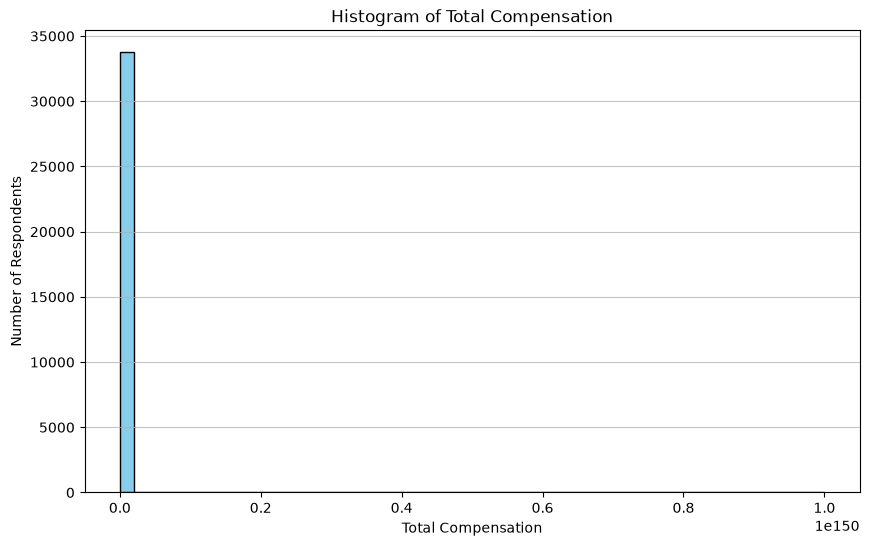

In [12]:
import matplotlib.pyplot as plt

# 1. Загружаем данные из базы в DataFrame
QUERY = """
SELECT CompTotal 
FROM main
"""
df_comp = pd.read_sql_query(QUERY, conn)

# 2. Строим гистограмму, предварительно удалив пустые значения (NaN)
plt.figure(figsize=(10, 6))
plt.hist(df_comp['CompTotal'].dropna(), bins=50, color='skyblue', edgecolor='black')

# 3. Добавляем оформление
plt.title('Histogram of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.75)

# 4. Показываем график
plt.show()


**Box Plots**

Plot a box plot of Age.


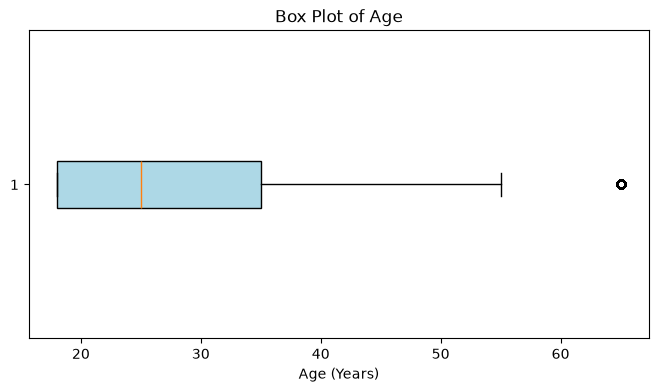

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Извлекаем данные о возрасте
QUERY = "SELECT Age FROM main"
df_age = pd.read_sql_query(QUERY, conn)

# 2. Извлекаем первое число из строки с помощью регулярного выражения
# Например, "18-24 years old" превратится в число 18
df_age['Age_numeric'] = df_age['Age'].str.extract(r'(\d+)').astype(float)

# 3. Строим корректный Box Plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_age['Age_numeric'].dropna(), orientation='horizontal', patch_artist=True, boxprops=dict(facecolor='lightblue'))

# Оформление
plt.title('Box Plot of Age')
plt.xlabel('Age (Years)')
plt.show()


### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


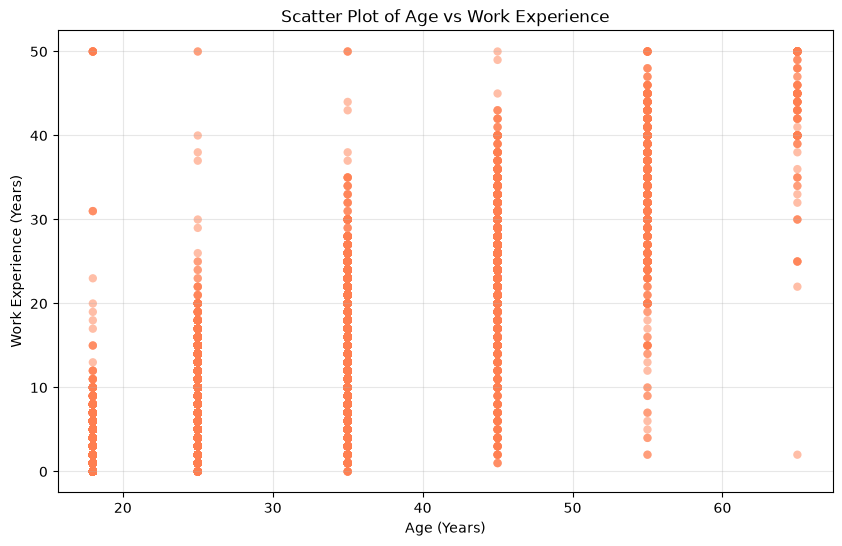

In [16]:
# Выбираем возраст и опыт работы
QUERY = "SELECT Age, WorkExp FROM main"
df_scatter = pd.read_sql_query(QUERY, conn)

# Превращаем текст в числа (извлекаем цифры)
df_scatter['Age'] = df_scatter['Age'].str.extract(r'(\d+)').astype(float)
df_scatter['WorkExp'] = pd.to_numeric(df_scatter['WorkExp'], errors='coerce')

# Удаляем пустые строки
df_scatter = df_scatter.dropna()

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(df_scatter['Age'], df_scatter['WorkExp'], alpha=0.5, color='coral', edgecolors='none')
plt.title('Scatter Plot of Age vs Work Experience')
plt.xlabel('Age (Years)')
plt.ylabel('Work Experience (Years)')
plt.grid(True, alpha=0.3)
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


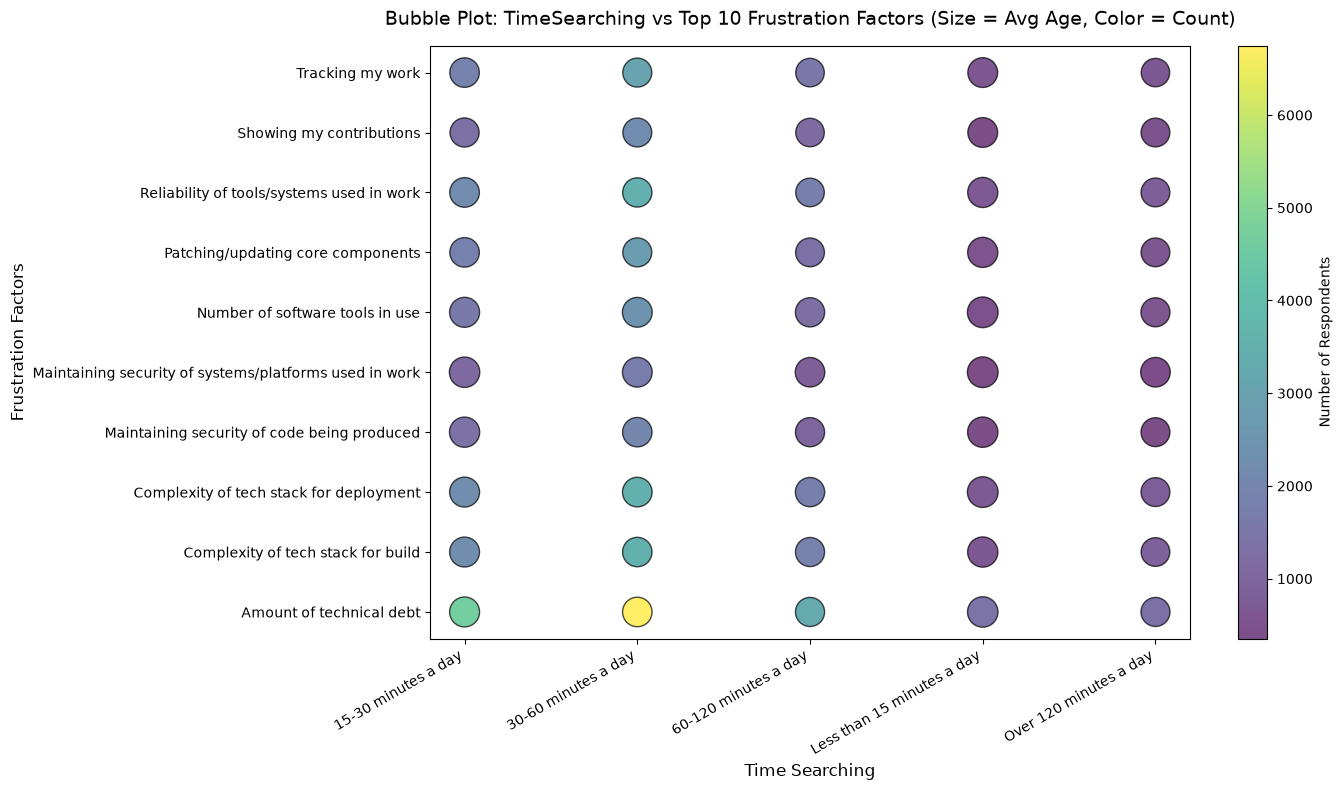

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Загружаем данные
QUERY = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL AND Frustration IS NOT NULL
"""
df_bubble = pd.read_sql_query(QUERY, conn)

# 2. Очищаем возраст: вытаскиваем первое число из диапазона
df_bubble['Age_num'] = df_bubble['Age'].str.extract(r'(\d+)').astype(float)

# 3. Разделяем множественные причины фрустрации (так как они записаны через ';')
df_bubble['Frustration'] = df_bubble['Frustration'].str.split(';')
df_bubble = df_bubble.explode('Frustration')

# Ограничимся топ-10 самыми частыми причинами фрустрации, чтобы график был читаемым
top_frustrations = df_bubble['Frustration'].value_counts().head(10).index
df_bubble = df_bubble[df_bubble['Frustration'].isin(top_frustrations)]

# 4. Группируем данные для подсчета среднего возраста и количества
grouped = df_bubble.groupby(['TimeSearching', 'Frustration']).agg(
    Avg_Age=('Age_num', 'mean'),
    Count=('Age_num', 'count')
).reset_index().dropna()

# 5. Превращаем категории в упорядоченные коды для осей X и Y
x_categories = grouped['TimeSearching'].unique()
y_categories = grouped['Frustration'].unique()

grouped['X_code'] = grouped['TimeSearching'].apply(lambda x: list(x_categories).index(x))
grouped['Y_code'] = grouped['Frustration'].apply(lambda x: list(y_categories).index(x))

# 6. Строим пузырьковый график
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    grouped['X_code'], 
    grouped['Y_code'], 
    s=grouped['Avg_Age'] * 15,     # Размер пузырька зависит от возраста
    c=grouped['Count'],            # Цвет пузырька зависит от количества
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='black'
)

# Заменяем числовые подписи осей на аккуратный текст
plt.xticks(range(len(x_categories)), x_categories, rotation=30, ha='right')
plt.yticks(range(len(y_categories)), y_categories)

# Оформление
plt.title('Bubble Plot: TimeSearching vs Top 10 Frustration Factors (Size = Avg Age, Color = Count)', fontsize=14, pad=15)
plt.xlabel('Time Searching', fontsize=12)
plt.ylabel('Frustration Factors', fontsize=12)
plt.colorbar(scatter, label='Number of Respondents')
plt.tight_layout()
plt.show()


### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


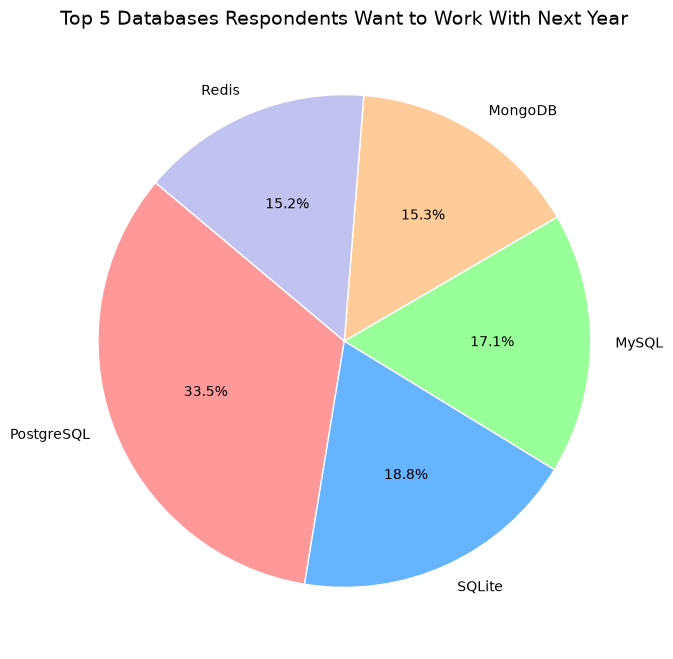

In [24]:
# Получаем данные о желаемых базах данных
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

# Разделяем базы данных (они записаны через точку с запятой) и считаем топ-5
all_dbs = df_db['DatabaseWantToWorkWith'].str.split(';').explode()
top_5_dbs = all_dbs.value_counts().head(5)

# Строим Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(top_5_dbs, labels=top_5_dbs.index, autopct='%1.1f%%', startangle=140, 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'], 
        wedgeprops=dict(edgecolor='white', linewidth=1))  # <- Вот здесь исправили!

plt.title('Top 5 Databases Respondents Want to Work With Next Year', fontsize=14)
plt.show()


**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


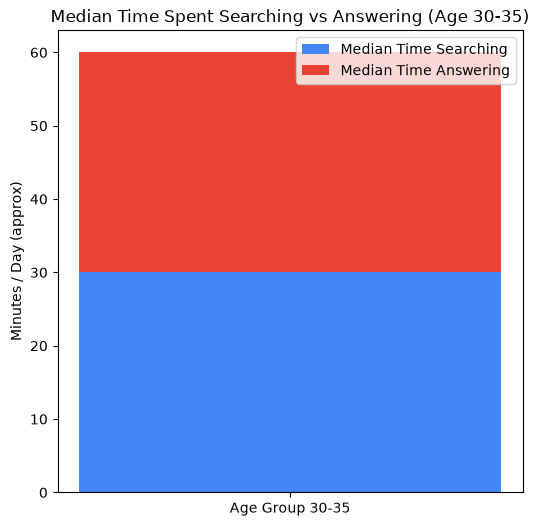

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Извлекаем нужные данные
QUERY = "SELECT TimeSearching, TimeAnswering, Age FROM main WHERE Age IS NOT NULL"
df_stacked = pd.read_sql_query(QUERY, conn)

# 2. Очищаем возраст и фильтруем группу от 30 до 35 лет
df_stacked['Age_num'] = df_stacked['Age'].str.extract(r'(\d+)').astype(float)
df_filtered = df_stacked[(df_stacked['Age_num'] >= 30) & (df_stacked['Age_num'] <= 35)].copy()

# 3. Переводим текстовое время в числа (берем первое число из диапазона)
df_filtered['TimeSearching_num'] = df_filtered['TimeSearching'].str.extract(r'(\d+)').astype(float)
df_filtered['TimeAnswering_num'] = df_filtered['TimeAnswering'].str.extract(r'(\d+)').astype(float)

# Удаляем пустые значения перед расчетом медианы
df_filtered = df_filtered.dropna(subset=['TimeSearching_num', 'TimeAnswering_num'])

# 4. Считаем медианы
median_search = df_filtered['TimeSearching_num'].median()
median_answer = df_filtered['TimeAnswering_num'].median()

# 5. Строим накопительную диаграмму (Stacked Bar)
plt.figure(figsize=(6, 6))
plt.bar(['Age Group 30-35'], [median_search], color='#4285F4', label='Median Time Searching')
plt.bar(['Age Group 30-35'], [median_answer], bottom=median_search, color='#EA4335', label='Median Time Answering')

# Оформление
plt.title('Median Time Spent Searching vs Answering (Age 30-35)', fontsize=12)
plt.ylabel('Minutes / Day (approx)')
plt.legend()
plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


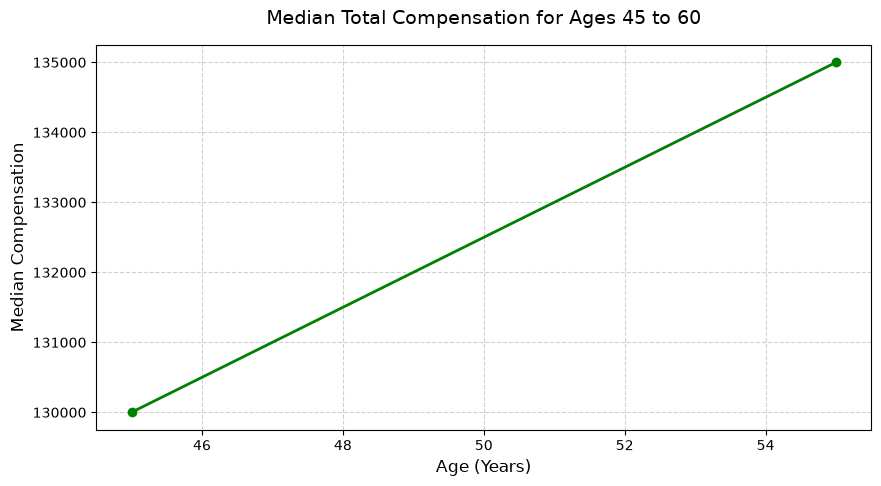

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Загружаем компенсацию и возраст
QUERY = "SELECT CompTotal, Age FROM main WHERE CompTotal IS NOT NULL AND Age IS NOT NULL"
df_line = pd.read_sql_query(QUERY, conn)

# 2. Очищаем данные от текста (извлекаем только цифры)
df_line['Age_num'] = df_line['Age'].str.extract(r'(\d+)').astype(float)
df_line['CompTotal'] = pd.to_numeric(df_line['CompTotal'], errors='coerce')

# 3. Фильтруем строго по возрасту от 45 до 60 и удаляем пропуски
df_line_filtered = df_line[(df_line['Age_num'] >= 45) & (df_line['Age_num'] <= 60)].dropna()

# 4. Группируем по возрасту и считаем медианную зарплату
median_comp_by_age = df_line_filtered.groupby('Age_num')['CompTotal'].median().reset_index()

# 5. Строим линейный график
plt.figure(figsize=(10, 5))
plt.plot(median_comp_by_age['Age_num'], median_comp_by_age['CompTotal'], marker='o', color='green', linewidth=2, markersize=6)

# Оформление
plt.title('Median Total Compensation for Ages 45 to 60', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Median Compensation', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


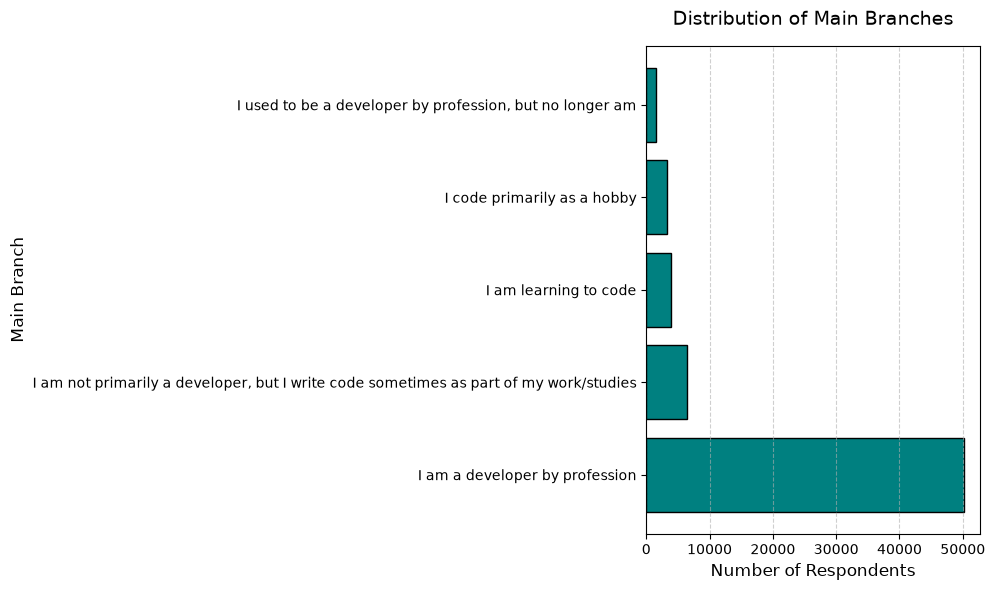

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Загружаем колонку MainBranch
QUERY = "SELECT MainBranch FROM main WHERE MainBranch IS NOT NULL"
df_bar = pd.read_sql_query(QUERY, conn)

# 2. Считаем количество упоминаний каждой категории
branch_counts = df_bar['MainBranch'].value_counts()

# 3. Строим горизонтальный Bar Chart
plt.figure(figsize=(10, 6))
# Используем barh для горизонтального отображения
plt.barh(branch_counts.index, branch_counts.values, color='teal', edgecolor='black')

# Оформление
plt.title('Distribution of Main Branches', fontsize=14, pad=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Автоматическое выравнивание отступов, чтобы длинный текст слева не обрезался
plt.tight_layout()
plt.show()


### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [28]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
